In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/BIGDATA_INSTACART/final_merged.zip"
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Selesai unzip")

Selesai unzip


In [6]:
import pandas as pd

sample = pd.read_csv(
    '/content/extracted/final_merged.csv',
    sep=';',
    nrows=5,
    engine='python'
)

sample

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,product_name,aisle_id,aisle,department_id,department,add_to_cart_order,reordered
0,2,202279,3,5,9,8,1819,All Natural No Stir Creamy Almond Butter ...,88,spreads,13,pantry,8,1
1,2,202279,3,5,9,8,9327,Garlic Powder ...,104,spices seasonings,13,pantry,3,0
2,2,202279,3,5,9,8,17794,Carrots ...,83,fresh vegetables,4,produce,6,1
3,2,202279,3,5,9,8,28985,Michigan Organic Kale ...,83,fresh vegetables,4,produce,2,1
4,2,202279,3,5,9,8,33120,Organic Egg Whites ...,86,eggs,16,dairy eggs,1,1


## **Import Library dan Export File**

In [7]:
!pip install duckdb -q

In [8]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
file_path = '/content/extracted/final_merged.csv'

In [9]:
con.execute(f"""
SELECT *
FROM read_csv_auto('{file_path}')
LIMIT 10
""").df()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,product_name,aisle_id,aisle,department_id,department,add_to_cart_order,reordered
0,2,202279,3,5,9,8,1819,All Natural No Stir Creamy Almond Butter ...,88,spreads,13,pantry,8,1
1,2,202279,3,5,9,8,9327,Garlic Powder ...,104,spices seasonings,13,pantry,3,0
2,2,202279,3,5,9,8,17794,Carrots ...,83,fresh vegetables,4,produce,6,1
3,2,202279,3,5,9,8,28985,Michigan Organic Kale ...,83,fresh vegetables,4,produce,2,1
4,2,202279,3,5,9,8,33120,Organic Egg Whites ...,86,eggs,16,dairy eggs,1,1
5,2,202279,3,5,9,8,40141,Original Unflavored Gelatine Mix ...,105,doughs gelatins bake mixes,13,pantry,7,1
6,2,202279,3,5,9,8,43668,Classic Blend Cole Slaw ...,123,packaged vegetables fruits,4,produce,9,0
7,2,202279,3,5,9,8,30035,Natural Sweetener ...,17,baking ingredients,13,pantry,5,0
8,2,202279,3,5,9,8,45918,Coconut Butter ...,19,oils vinegars,13,pantry,4,1
9,3,205970,16,5,17,12,17461,Air Chilled Organic Boneless Skinless Chicken ...,35,poultry counter,12,meat seafood,7,1


In [10]:
con.execute(f"""
SELECT COUNT(*) AS total_rows
FROM read_csv_auto('{file_path}')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows
0,32434489


In [11]:
con.execute(f"""
SELECT
  COUNT(*) AS total_rows
FROM read_csv_auto('{file_path}')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows
0,32434489


In [12]:
con.execute(f"""
SELECT
  SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) AS missing_user_id,
  SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS missing_product_id
FROM read_csv_auto('{file_path}')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_user_id,missing_product_id
0,0.0,0.0


In [13]:
cols = con.execute(f"""
DESCRIBE SELECT *
FROM read_csv_auto('{file_path}')
""").df()

cols

,column_name,column_type,null,key,default,extra
0,order_id,BIGINT,YES,None,None,None
1,user_id,BIGINT,YES,None,None,None
2,order_number,BIGINT,YES,None,None,None
3,order_dow,BIGINT,YES,None,None,None
4,order_hour_of_day,BIGINT,YES,None,None,None
5,days_since_prior_order,BIGINT,YES,None,None,None
6,product_id,BIGINT,YES,None,None,None
7,product_name,VARCHAR,YES,None,None,None
8,aisle_id,BIGINT,YES,None,None,None
9,aisle,VARCHAR,YES,None,None,None


In [14]:
cols = con.execute(f"""
DESCRIBE SELECT *
FROM read_csv_auto('/content/extracted/final_merged.csv')
""").df()['column_name'].tolist()

query = ", ".join([
    f"COUNT(*) FILTER (WHERE {c} IS NULL) AS missing_{c}"
    for c in cols
])

con.execute(f"""
SELECT {query}
FROM read_csv_auto('/content/extracted/final_merged.csv')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_order_id,missing_user_id,missing_order_number,missing_order_dow,missing_order_hour_of_day,missing_days_since_prior_order,missing_product_id,missing_product_name,missing_aisle_id,missing_aisle,missing_department_id,missing_department,missing_add_to_cart_order,missing_reordered
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
con.execute(f"""
SELECT user_id, COUNT(*) AS total_orders
FROM read_csv_auto('{file_path}')
GROUP BY user_id
ORDER BY total_orders DESC
LIMIT 10
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,total_orders
0,201268,3725
1,129928,3638
2,164055,3061
3,186704,2936
4,176478,2921
5,182401,2907
6,137629,2901
7,33731,2888
8,108187,2760
9,4694,2735


# **EDA**

## 1. DISTRIBUSI ORDER PER JAM

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

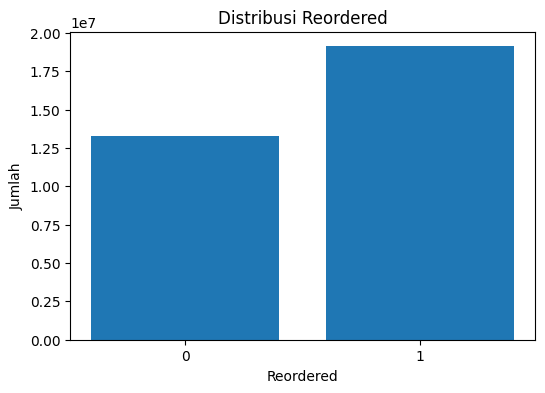

In [16]:
df = con.execute(f"""
SELECT reordered, COUNT(*) AS total
FROM read_csv_auto('{file_path}')
GROUP BY reordered
""").df()

plt.figure(figsize=(6,4))
plt.bar(df['reordered'].astype(str), df['total'])
plt.title('Distribusi Reordered')
plt.xlabel('Reordered')
plt.ylabel('Jumlah')
plt.show()

## 2. Top 20 Produk Paling Sering Dibeli

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

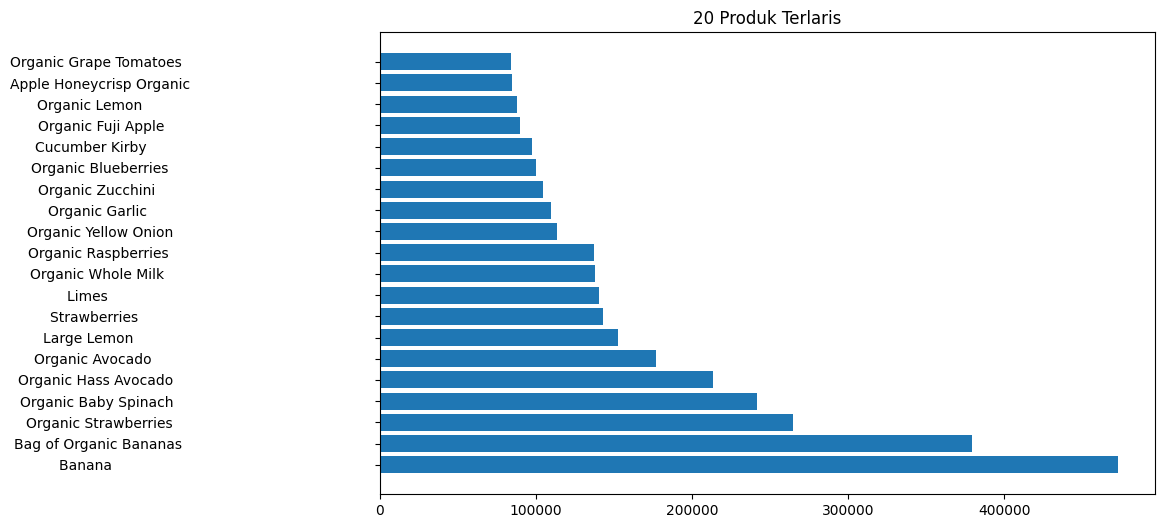

In [17]:
df = con.execute(f"""
SELECT product_name, COUNT(*) total
FROM read_csv_auto('{file_path}')
GROUP BY product_name
ORDER BY total DESC
LIMIT 20
""").df()

plt.figure(figsize=(10,6))
plt.barh(df['product_name'], df['total'])
plt.title('20 Produk Terlaris')
plt.show()

## 3. Top 20 Produk dengan Reorder Tertinggi

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

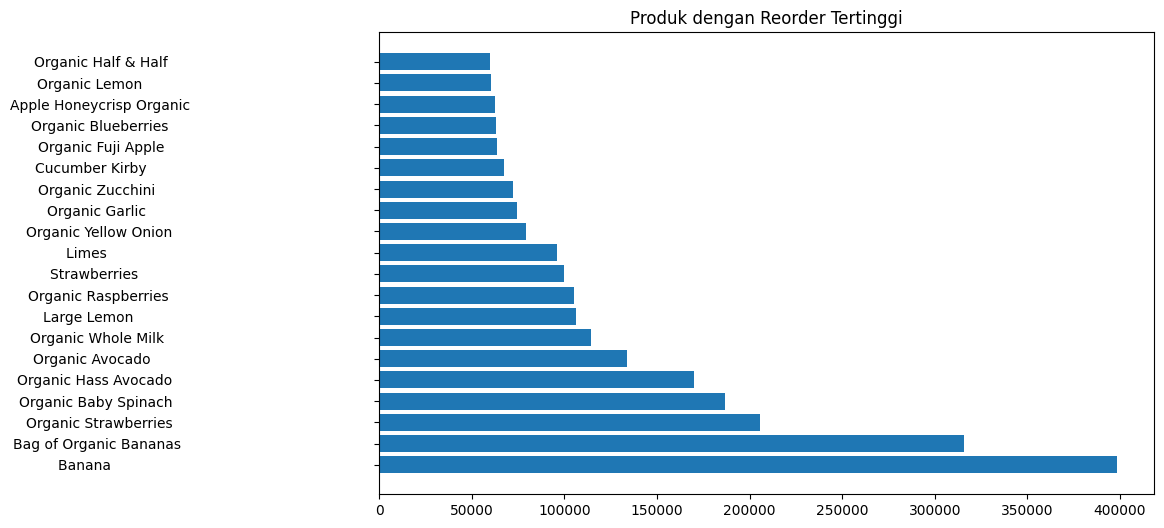

In [18]:
df = con.execute(f"""
SELECT product_name,
       SUM(reordered) AS total_reorder
FROM read_csv_auto('{file_path}')
GROUP BY product_name
ORDER BY total_reorder DESC
LIMIT 20
""").df()

plt.figure(figsize=(10,6))
plt.barh(df['product_name'], df['total_reorder'])
plt.title('Produk dengan Reorder Tertinggi')
plt.show()

## 4. Pola Belanja Berdasarkan Jam

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

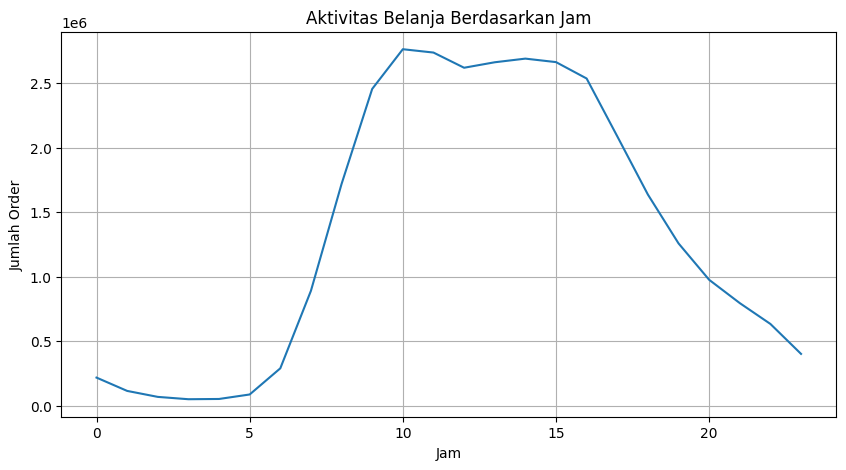

In [19]:
df = con.execute(f"""
SELECT order_hour_of_day,
       COUNT(*) total
FROM read_csv_auto('{file_path}')
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
""").df()

plt.figure(figsize=(10,5))
plt.plot(df['order_hour_of_day'], df['total'])
plt.title('Aktivitas Belanja Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Order')
plt.grid()
plt.show()

## 5. Pola Belanja Berdasarkan Hari

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

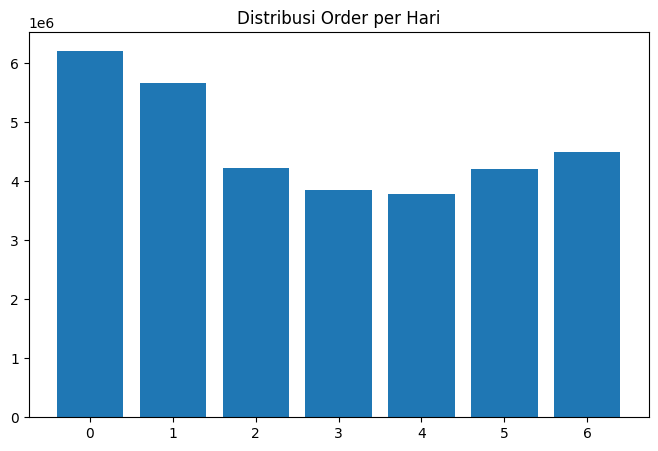

In [20]:
df = con.execute(f"""
SELECT order_dow,
       COUNT(*) total
FROM read_csv_auto('{file_path}')
GROUP BY order_dow
ORDER BY order_dow
""").df()

plt.figure(figsize=(8,5))
plt.bar(df['order_dow'], df['total'])
plt.title('Distribusi Order per Hari')
plt.show()

## 6. Distribusi Basket Size

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

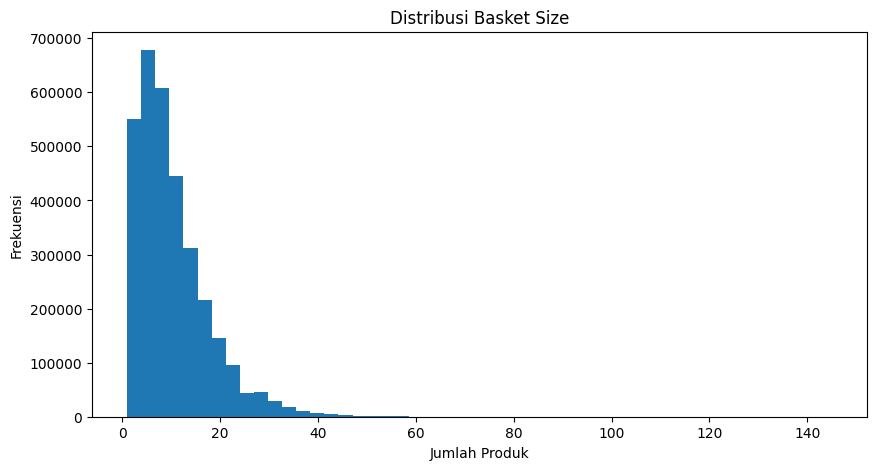

In [21]:
df = con.execute(f"""
SELECT order_id,
       COUNT(*) basket_size
FROM read_csv_auto('{file_path}')
GROUP BY order_id
""").df()

plt.figure(figsize=(10,5))
plt.hist(df['basket_size'], bins=50)
plt.title('Distribusi Basket Size')
plt.xlabel('Jumlah Produk')
plt.ylabel('Frekuensi')
plt.show()


## 7. Distribusi Days Since Prior Order

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

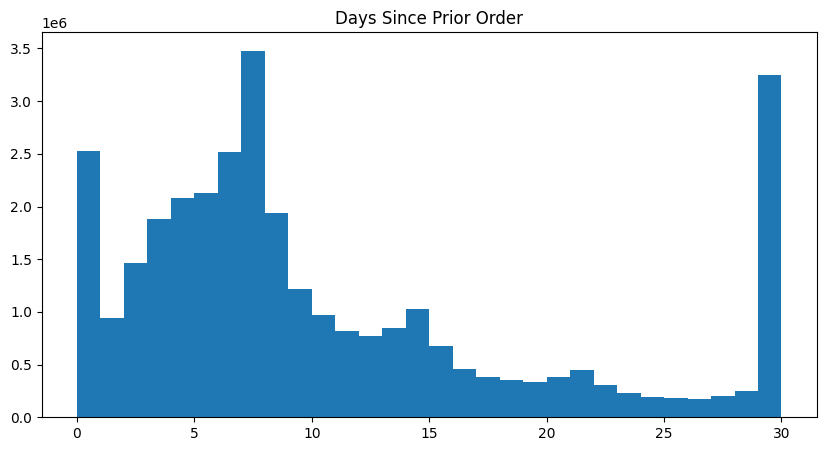

In [22]:
df = con.execute(f"""
SELECT days_since_prior_order
FROM read_csv_auto('{file_path}')
WHERE days_since_prior_order IS NOT NULL
""").df()

plt.figure(figsize=(10,5))
plt.hist(df['days_since_prior_order'], bins=30)
plt.title('Days Since Prior Order')
plt.show()

## 8. Reorder Rate Berdasarkan Jam

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

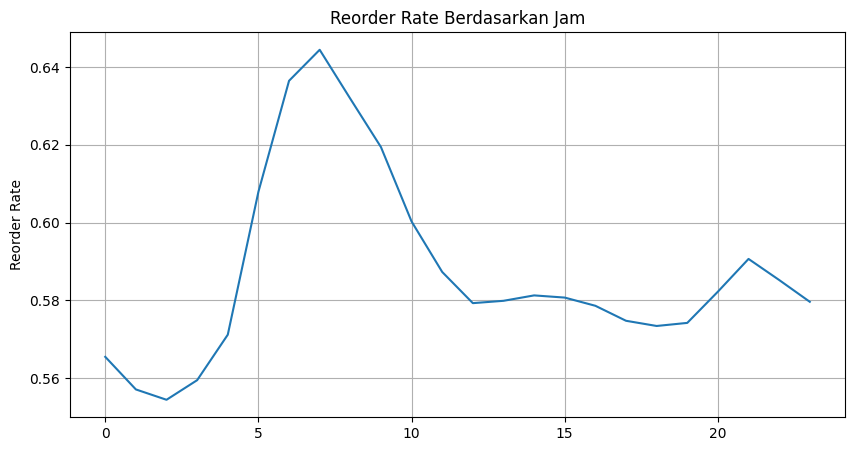

In [23]:
df = con.execute(f"""
SELECT order_hour_of_day,
       AVG(reordered) AS reorder_rate
FROM read_csv_auto('{file_path}')
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
""").df()

plt.figure(figsize=(10,5))
plt.plot(df['order_hour_of_day'],
         df['reorder_rate'])
plt.title('Reorder Rate Berdasarkan Jam')
plt.ylabel('Reorder Rate')
plt.grid()
plt.show()

## 9. Top Department

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

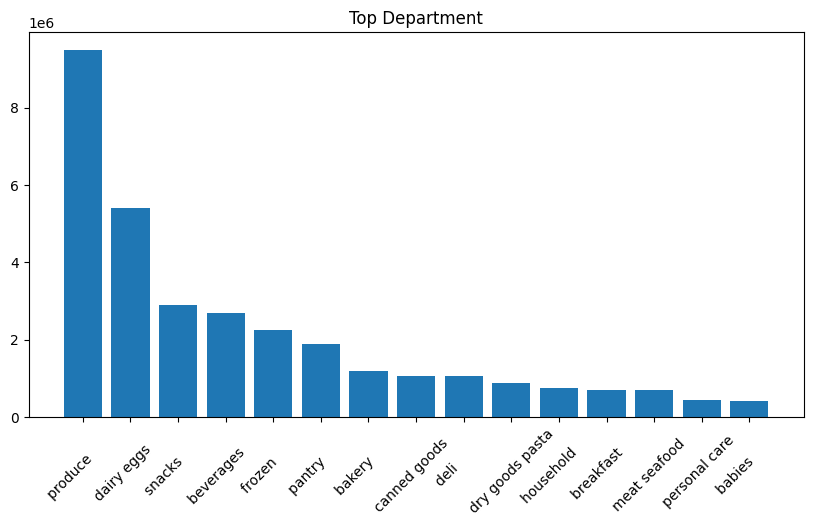

In [24]:
df = con.execute(f"""
SELECT department,
       COUNT(*) total
FROM read_csv_auto('{file_path}')
GROUP BY department
ORDER BY total DESC
LIMIT 15
""").df()

plt.figure(figsize=(10,5))
plt.bar(df['department'], df['total'])
plt.xticks(rotation=45)
plt.title('Top Department')
plt.show()

## 10. Heatmap Hari vs Jam

In [25]:
numeric_df = con.execute(f"""
SELECT
    user_id,
    product_id,
    order_number,
    add_to_cart_order,
    reordered,
    order_dow,
    order_hour_of_day,
    days_since_prior_order,
    aisle_id,
    department_id
FROM read_csv_auto('{file_path}')
WHERE days_since_prior_order IS NOT NULL
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [26]:
corr_matrix = numeric_df.corr(numeric_only=True)

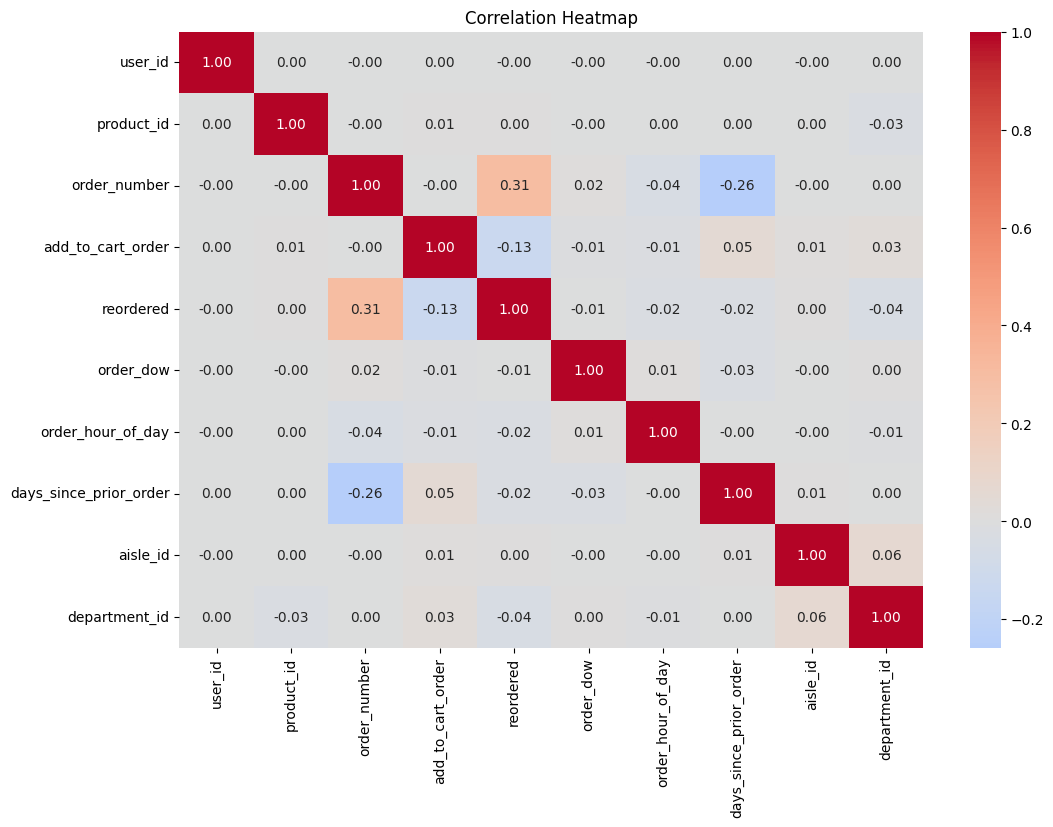

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## **AGREGRASI**

In [28]:
import duckdb
from google.colab import files

# Koneksi DuckDB
con = duckdb.connect()

# Lokasi file CSV utama
file_path = '/content/extracted/final_merged.csv'

# Agregasi per produk
product_summary = con.execute(f"""
SELECT
    product_id,
    product_name,

    COUNT(*) AS total_order,

    SUM(reordered) AS total_reorder,

    ROUND(
        SUM(reordered) * 100.0 / COUNT(*),
        2
    ) AS reorder_rate

FROM read_csv_auto('{file_path}')

GROUP BY
    product_id,
    product_name

ORDER BY product_id ASC
""").df()

# Simpan ke CSV
output_file = 'product_summary.csv'

product_summary.to_csv(
    output_file,
    index=False
)

# Tampilkan preview
print(f"Jumlah produk: {len(product_summary):,}")
display(product_summary.head())

# Download CSV
files.download(output_file)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Jumlah produk: 49,677


,product_id,product_name,total_order,total_reorder,reorder_rate
0,1,Chocolate Sandwich Cookies ...,1852,1136.0,61.34
1,2,All-Seasons Salt ...,90,12.0,13.33
2,3,Robust Golden Unsweetened Oolong Tea ...,277,203.0,73.29
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,329,147.0,44.68
4,5,Green Chile Anytime Sauce ...,15,9.0,60.00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **EDA 2**

## 1. Histogram Total Order

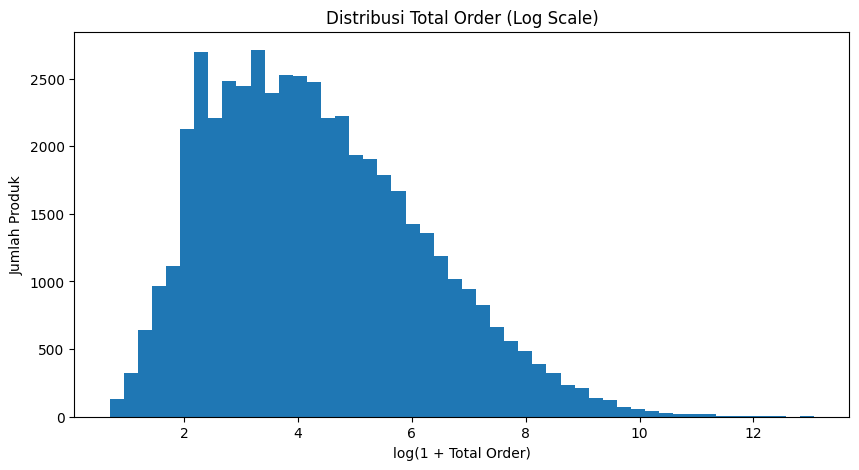

In [29]:

plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(product_summary['total_order']),
    bins=50
)

plt.title('Distribusi Total Order (Log Scale)')
plt.xlabel('log(1 + Total Order)')
plt.ylabel('Jumlah Produk')

plt.show()

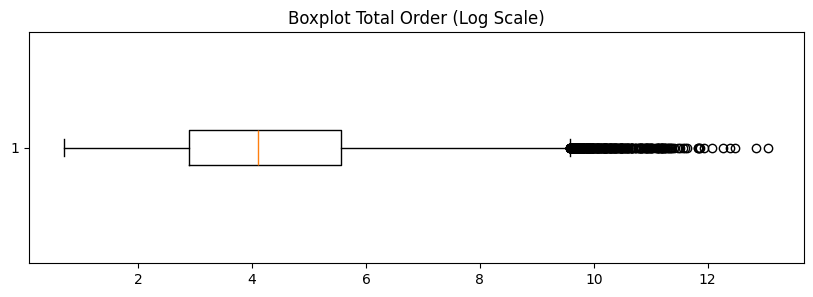

In [30]:
plt.figure(figsize=(10,3))

plt.boxplot(
    np.log1p(product_summary['total_order']),
    vert=False
)

plt.title('Boxplot Total Order (Log Scale)')
plt.show()

## 2. Histogram Total Reorder

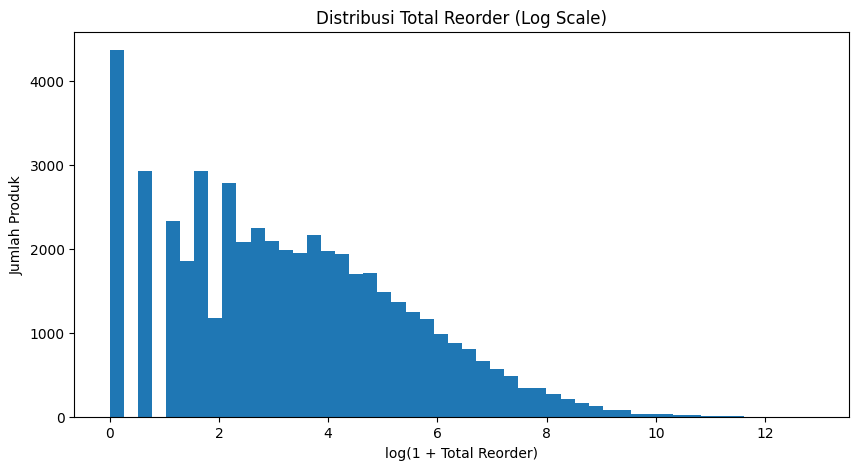

In [31]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(product_summary['total_reorder']),
    bins=50
)

plt.title('Distribusi Total Reorder (Log Scale)')
plt.xlabel('log(1 + Total Reorder)')
plt.ylabel('Jumlah Produk')

plt.show()

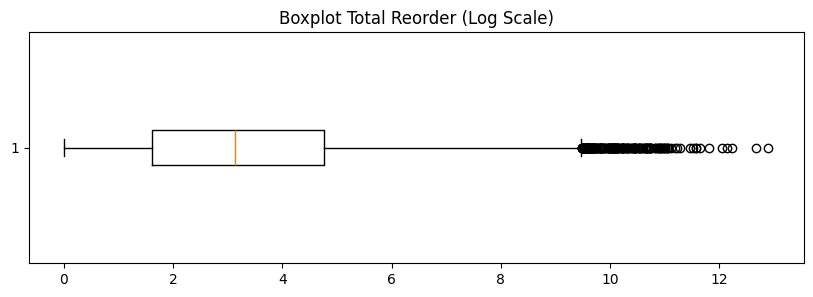

In [32]:
plt.figure(figsize=(10,3))

plt.boxplot(
    np.log1p(product_summary['total_reorder']),
    vert=False
)

plt.title('Boxplot Total Reorder (Log Scale)')
plt.show()

## 3. Histogram Reorder Rate

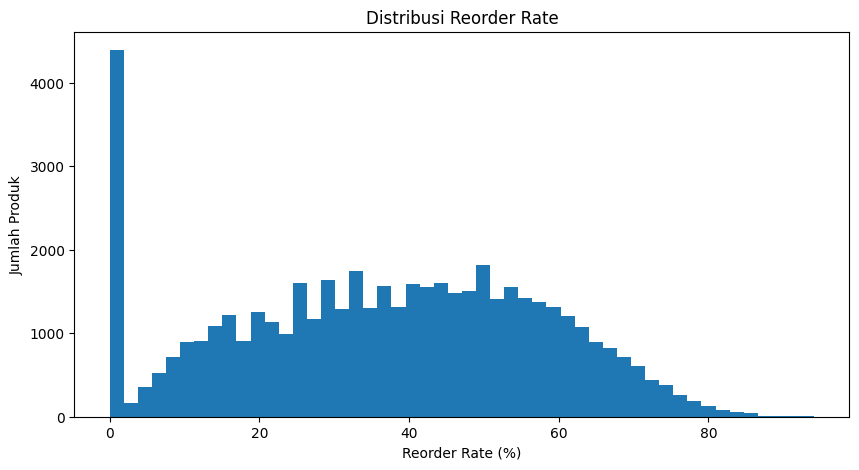

In [33]:
plt.figure(figsize=(10,5))

plt.hist(
    product_summary['reorder_rate'],
    bins=50
)

plt.title('Distribusi Reorder Rate')
plt.xlabel('Reorder Rate (%)')
plt.ylabel('Jumlah Produk')

plt.show()

## **MODELING**

In [34]:
import pandas as pd
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

df = pd.read_csv('product_summary.csv')

In [35]:
# HITUNG QUARTILE
Q1 = df['reorder_rate'].quantile(0.25)
Q2 = df['reorder_rate'].quantile(0.50)
Q3 = df['reorder_rate'].quantile(0.75)

print(Q1,Q2,Q3)

20.81 37.66 52.93


In [36]:
# LABELING QUARTILE
def kategori(rate):

    if rate <= Q1:
        return "Rendah"

    elif rate <= Q2:
        return "Sedang"

    elif rate <= Q3:
        return "Tinggi"

    else:
        return "Sangat Tinggi"

In [37]:
# TAMBAH KOLOM
df['prioritas_restok'] = (
    df['reorder_rate']
    .apply(kategori)
)

In [38]:
df.head()

,product_id,product_name,total_order,total_reorder,reorder_rate,prioritas_restok
0,1,Chocolate Sandwich Cookies ...,1852,1136.0,61.34,Sangat Tinggi
1,2,All-Seasons Salt ...,90,12.0,13.33,Rendah
2,3,Robust Golden Unsweetened Oolong Tea ...,277,203.0,73.29,Sangat Tinggi
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,329,147.0,44.68,Tinggi
4,5,Green Chile Anytime Sauce ...,15,9.0,60.00,Sangat Tinggi


In [39]:
mapping = {
    'Rendah': 0,
    'Sedang': 1,
    'Tinggi': 2,
    'Sangat Tinggi': 3
}

df['target'] = df['prioritas_restok'].map(mapping)

In [40]:
# FEATURE SELECTION
X = df[
    [
        'total_order',
        'total_reorder'
    ]
]

y = df['target']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [45]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [46]:
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## HASIL EVALUASI

In [47]:
print(mapping)

{'Rendah': 0, 'Sedang': 1, 'Tinggi': 2, 'Sangat Tinggi': 3}


In [48]:
# EVALUASI
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== HASIL EVALUASI RANDOM FOREST ===\n")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred))

=== HASIL EVALUASI RANDOM FOREST ===

Accuracy  : 0.9925
Precision : 0.9925
Recall    : 0.9925
F1-Score  : 0.9925

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2484
           1       0.99      0.99      0.99      2485
           2       0.99      0.99      0.99      2483
           3       0.99      0.99      0.99      2484

    accuracy                           0.99      9936
   macro avg       0.99      0.99      0.99      9936
weighted avg       0.99      0.99      0.99      9936



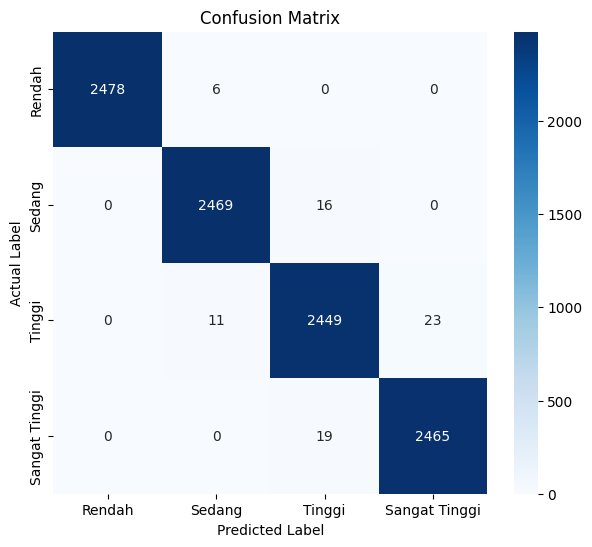

In [50]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

# Nama kelas
class_names = [
    'Rendah',
    'Sedang',
    'Tinggi',
    'Sangat Tinggi'
]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [51]:
from sklearn.metrics import accuracy_score

best_acc = 0
best_tree = None
best_idx = None

for i, tree in enumerate(rf.estimators_):

    pred = tree.predict(X_test)

    acc = accuracy_score(y_test, pred)

    if acc > best_acc:
        best_acc = acc
        best_tree = tree
        best_idx = i

print(f"Tree terbaik: {best_idx}")
print(f"Accuracy: {best_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

Tree terbaik: 116
Accuracy: 0.9834


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

Tree dengan Akurasi Tertinggi

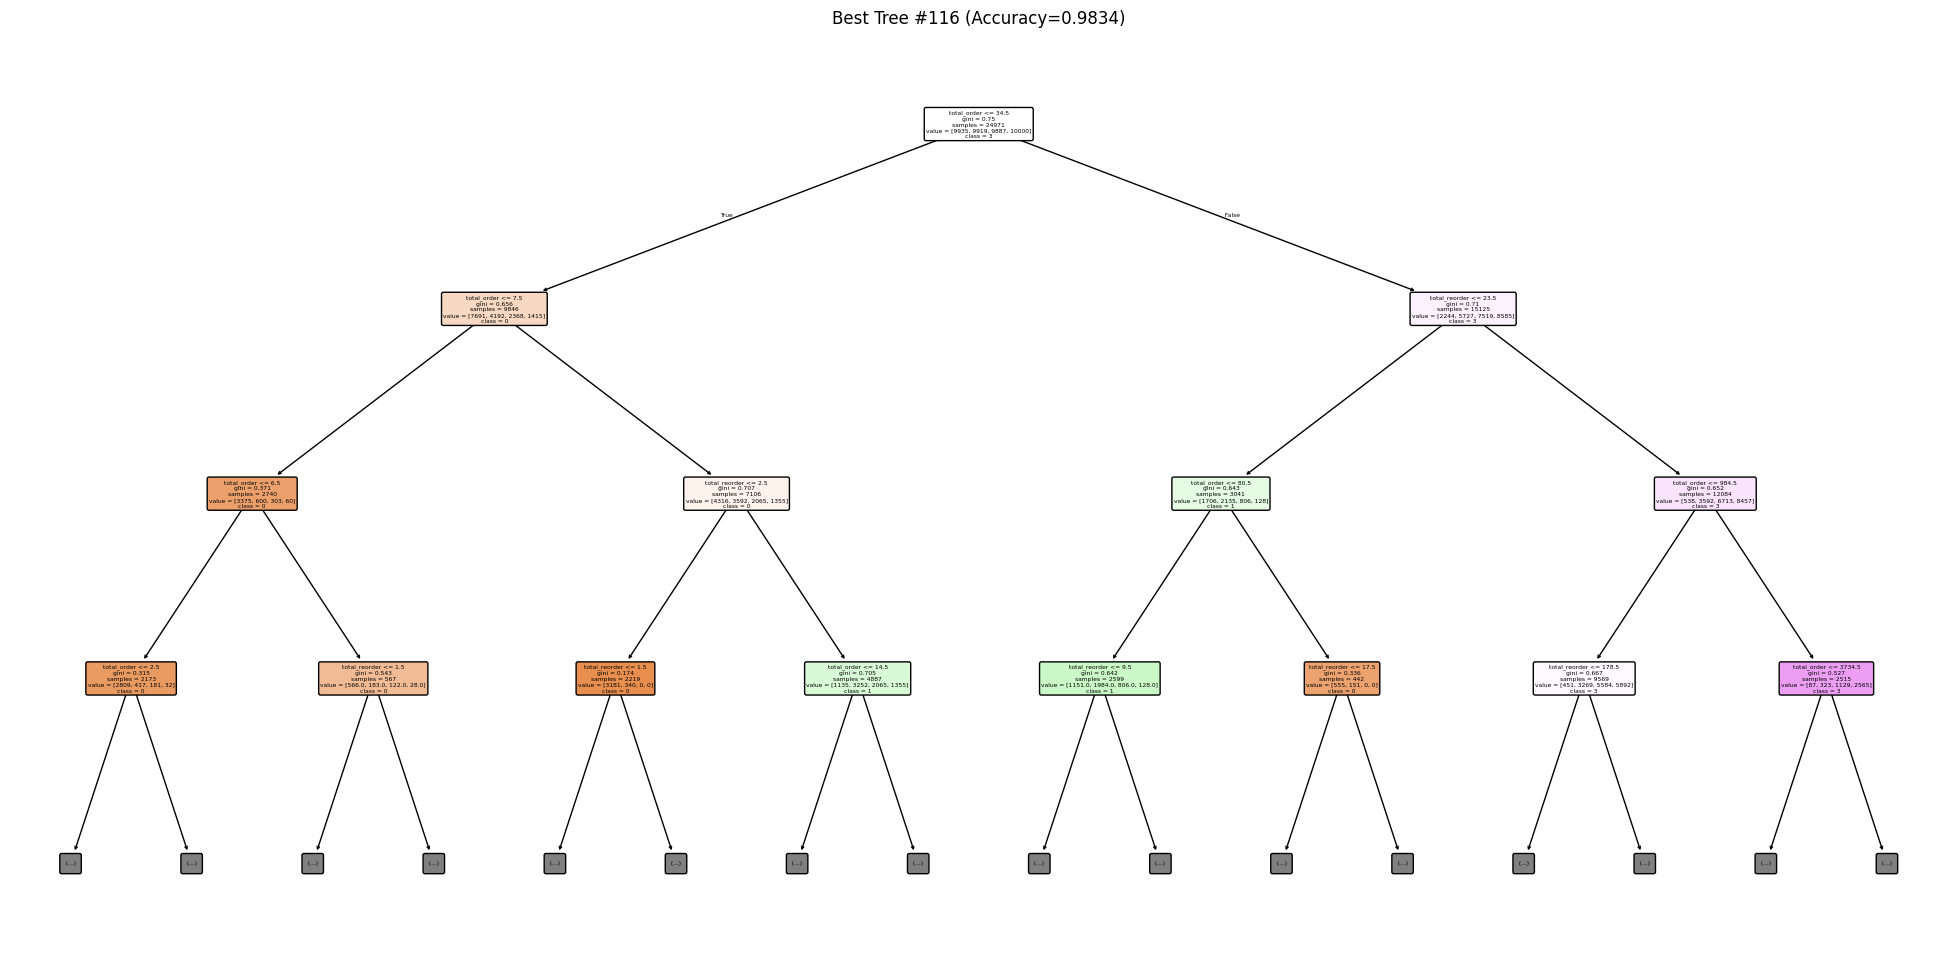

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,12))

plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in rf.classes_],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title(
    f"Best Tree #{best_idx} (Accuracy={best_acc:.4f})"
)

plt.show()